In [15]:
# Imports and Setup
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import simple_icd_10_cm as cm

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

current_dir = Path.cwd()

if str(current_dir) not in sys.path:
    sys.path.append(str(current_dir))

from src.utils import data_loader
from src.utils.preprocessing import ohe

# Ensure figures directory exists
FIGURES_DIR = current_dir / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
# Helper Functions for Extraction
def extract_feature_importances(cohort_dir, cohort_file, codes_file, model_type):
    """
    Loads data, builds combined OHE features, trains the model across 5 outer folds,
    and extracts normalized feature importances.
    """
    cohort_path = current_dir / 'data' / cohort_dir / cohort_file
    codes_path = current_dir / 'data' / cohort_dir / codes_file
    folds_dir = current_dir / 'data' / cohort_dir / 'cv_folds'
    
    # Load Data
    df_target, df_codes, valid_ids = data_loader.load_processed_data(cohort_path, codes_path)
    df_target = df_target.set_index('hadm_id')
    
    # Generate OHE Features
    feature_sets = ohe.generate_feature_sets(df_codes, min_percentage=0.0)
    X_full = feature_sets['Full Codes']
    X_combined = feature_sets['Combined']
    
    # Align target with features
    common_idx = X_combined.index.intersection(df_target.index)
    X_combined = X_combined.loc[common_idx]
    y = df_target.loc[common_idx, 'label'].astype(int)
    
    # We need the exact split index between Full Codes and Groups
    split_index = X_full.shape[1]
    feature_names = X_combined.columns.tolist()
    
    fold_files = data_loader.get_fold_files(folds_dir)
    
    all_fold_importances = []
    
    for i, fold_file in enumerate(fold_files):
        print(f"Processing Fold {i+1}/5...")
        train_idx, val_idx, test_idx = data_loader.load_single_fold(fold_file)
        
        # Combine train and val for training the model to extract importance
        full_train_idx = sorted(list(set(train_idx) | set(val_idx)))
        valid_train_idx = [idx for idx in full_train_idx if idx in X_combined.index]
        
        X_train = X_combined.loc[valid_train_idx]
        y_train = y.loc[valid_train_idx]
        
        # Initialize and train model
        if model_type == "CatBoost":
            model = CatBoostClassifier(verbose=0, random_state=42)
            model.fit(X_train, y_train)
            importances = model.get_feature_importance()
        elif model_type == "RandomForest":
            model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            importances = model.feature_importances_
            
        # Normalize to sum to 1
        if importances.sum() > 0:
            importances = importances / importances.sum()
            
        all_fold_importances.append(importances)
        
    # Average across folds
    avg_importances = np.mean(all_fold_importances, axis=0)
    
    # Split back into Full Codes and Groups using the exact index
    full_codes_imp = pd.DataFrame({
        'Feature': feature_names[:split_index],
        'Importance': avg_importances[:split_index]
    }).sort_values(by='Importance', ascending=False)
    
    groups_imp = pd.DataFrame({
        'Feature': feature_names[split_index:],
        'Importance': avg_importances[split_index:]
    }).sort_values(by='Importance', ascending=False)
    
    return full_codes_imp, groups_imp

In [11]:
# Execute for Aplasia (CatBoost)
print("--- Aplasia (Up-To-Admission) ---")
aplasia_full, aplasia_groups = extract_feature_importances(
    cohort_dir='mimic_cohort_aplasia_45_days',
    cohort_file='mimic_cohort_aplasia_45_days.csv.gz',
    codes_file='mimic_cohort_aplasia_45_days_icd_codes_upto.csv.gz',
    model_type='CatBoost'
)

print("\nTop 10 Full Codes (Aplasia):")
display(aplasia_full.head(10))

print("\nTop 10 Groups (Aplasia):")
display(aplasia_groups.head(10))

--- Aplasia (Up-To-Admission) ---
 Data Loaded. Total Patients in Cohort: 4539
Processing Fold 1/5...
Processing Fold 2/5...
Processing Fold 3/5...
Processing Fold 4/5...
Processing Fold 5/5...

Top 10 Full Codes (Aplasia):


,Feature,Importance
5562,R5081,0.039373
2340,C8599,0.035258
2370,C9200,0.028178
6824,Z888,0.026306
1957,C220,0.025000
3267,G936,0.019272
6610,Z5111,0.017559
2828,E8770,0.013967
2826,E876,0.008920
2274,C8339,0.008195



Top 10 Groups (Aplasia):


,Feature,Importance
886,G93,0.035716
639,C78,0.035025
1671,Z88,0.033813
646,C83,0.033244
653,C92,0.030905
595,C22,0.021972
651,C90,0.018467
1668,Z85,0.011746
640,C79,0.011174
708,D70,0.011089


In [12]:
# Execute for Neutropenic Fever (RandomForest)
print("--- Neutropenic Fever (Up-To-Admission) ---")
nf_full, nf_groups = extract_feature_importances(
    cohort_dir='mimic_cohort_NF_30_days',
    cohort_file='mimic_cohort_NF_30_days.csv.gz',
    codes_file='mimic_cohort_NF_30_days_icd_codes_upto.csv.gz',
    model_type='RandomForest'
)

print("\nTop 10 Full Codes (Neutropenic Fever):")
display(nf_full.head(10))

print("\nTop 10 Groups (Neutropenic Fever):")
display(nf_groups.head(10))

--- Neutropenic Fever (Up-To-Admission) ---
 Data Loaded. Total Patients in Cohort: 5308
Processing Fold 1/5...
Processing Fold 2/5...
Processing Fold 3/5...
Processing Fold 4/5...
Processing Fold 5/5...

Top 10 Full Codes (Neutropenic Fever):


,Feature,Importance
5830,R5081,0.005135
2472,C9200,0.004746
2473,C9201,0.004644
2639,D6481,0.003671
6932,Z5111,0.003492
2666,D701,0.003406
6243,T451X5A,0.003327
6837,Y929,0.003320
2671,D709,0.003293
4492,K5900,0.003106



Top 10 Groups (Neutropenic Fever):


,Feature,Importance
723,D70,0.005377
666,C92,0.005274
718,D64,0.003525
1428,R50,0.003467
722,D69,0.003251
1525,T45,0.003145
717,D63,0.003113
715,D61,0.003088
792,E87,0.003086
1093,K21,0.003074


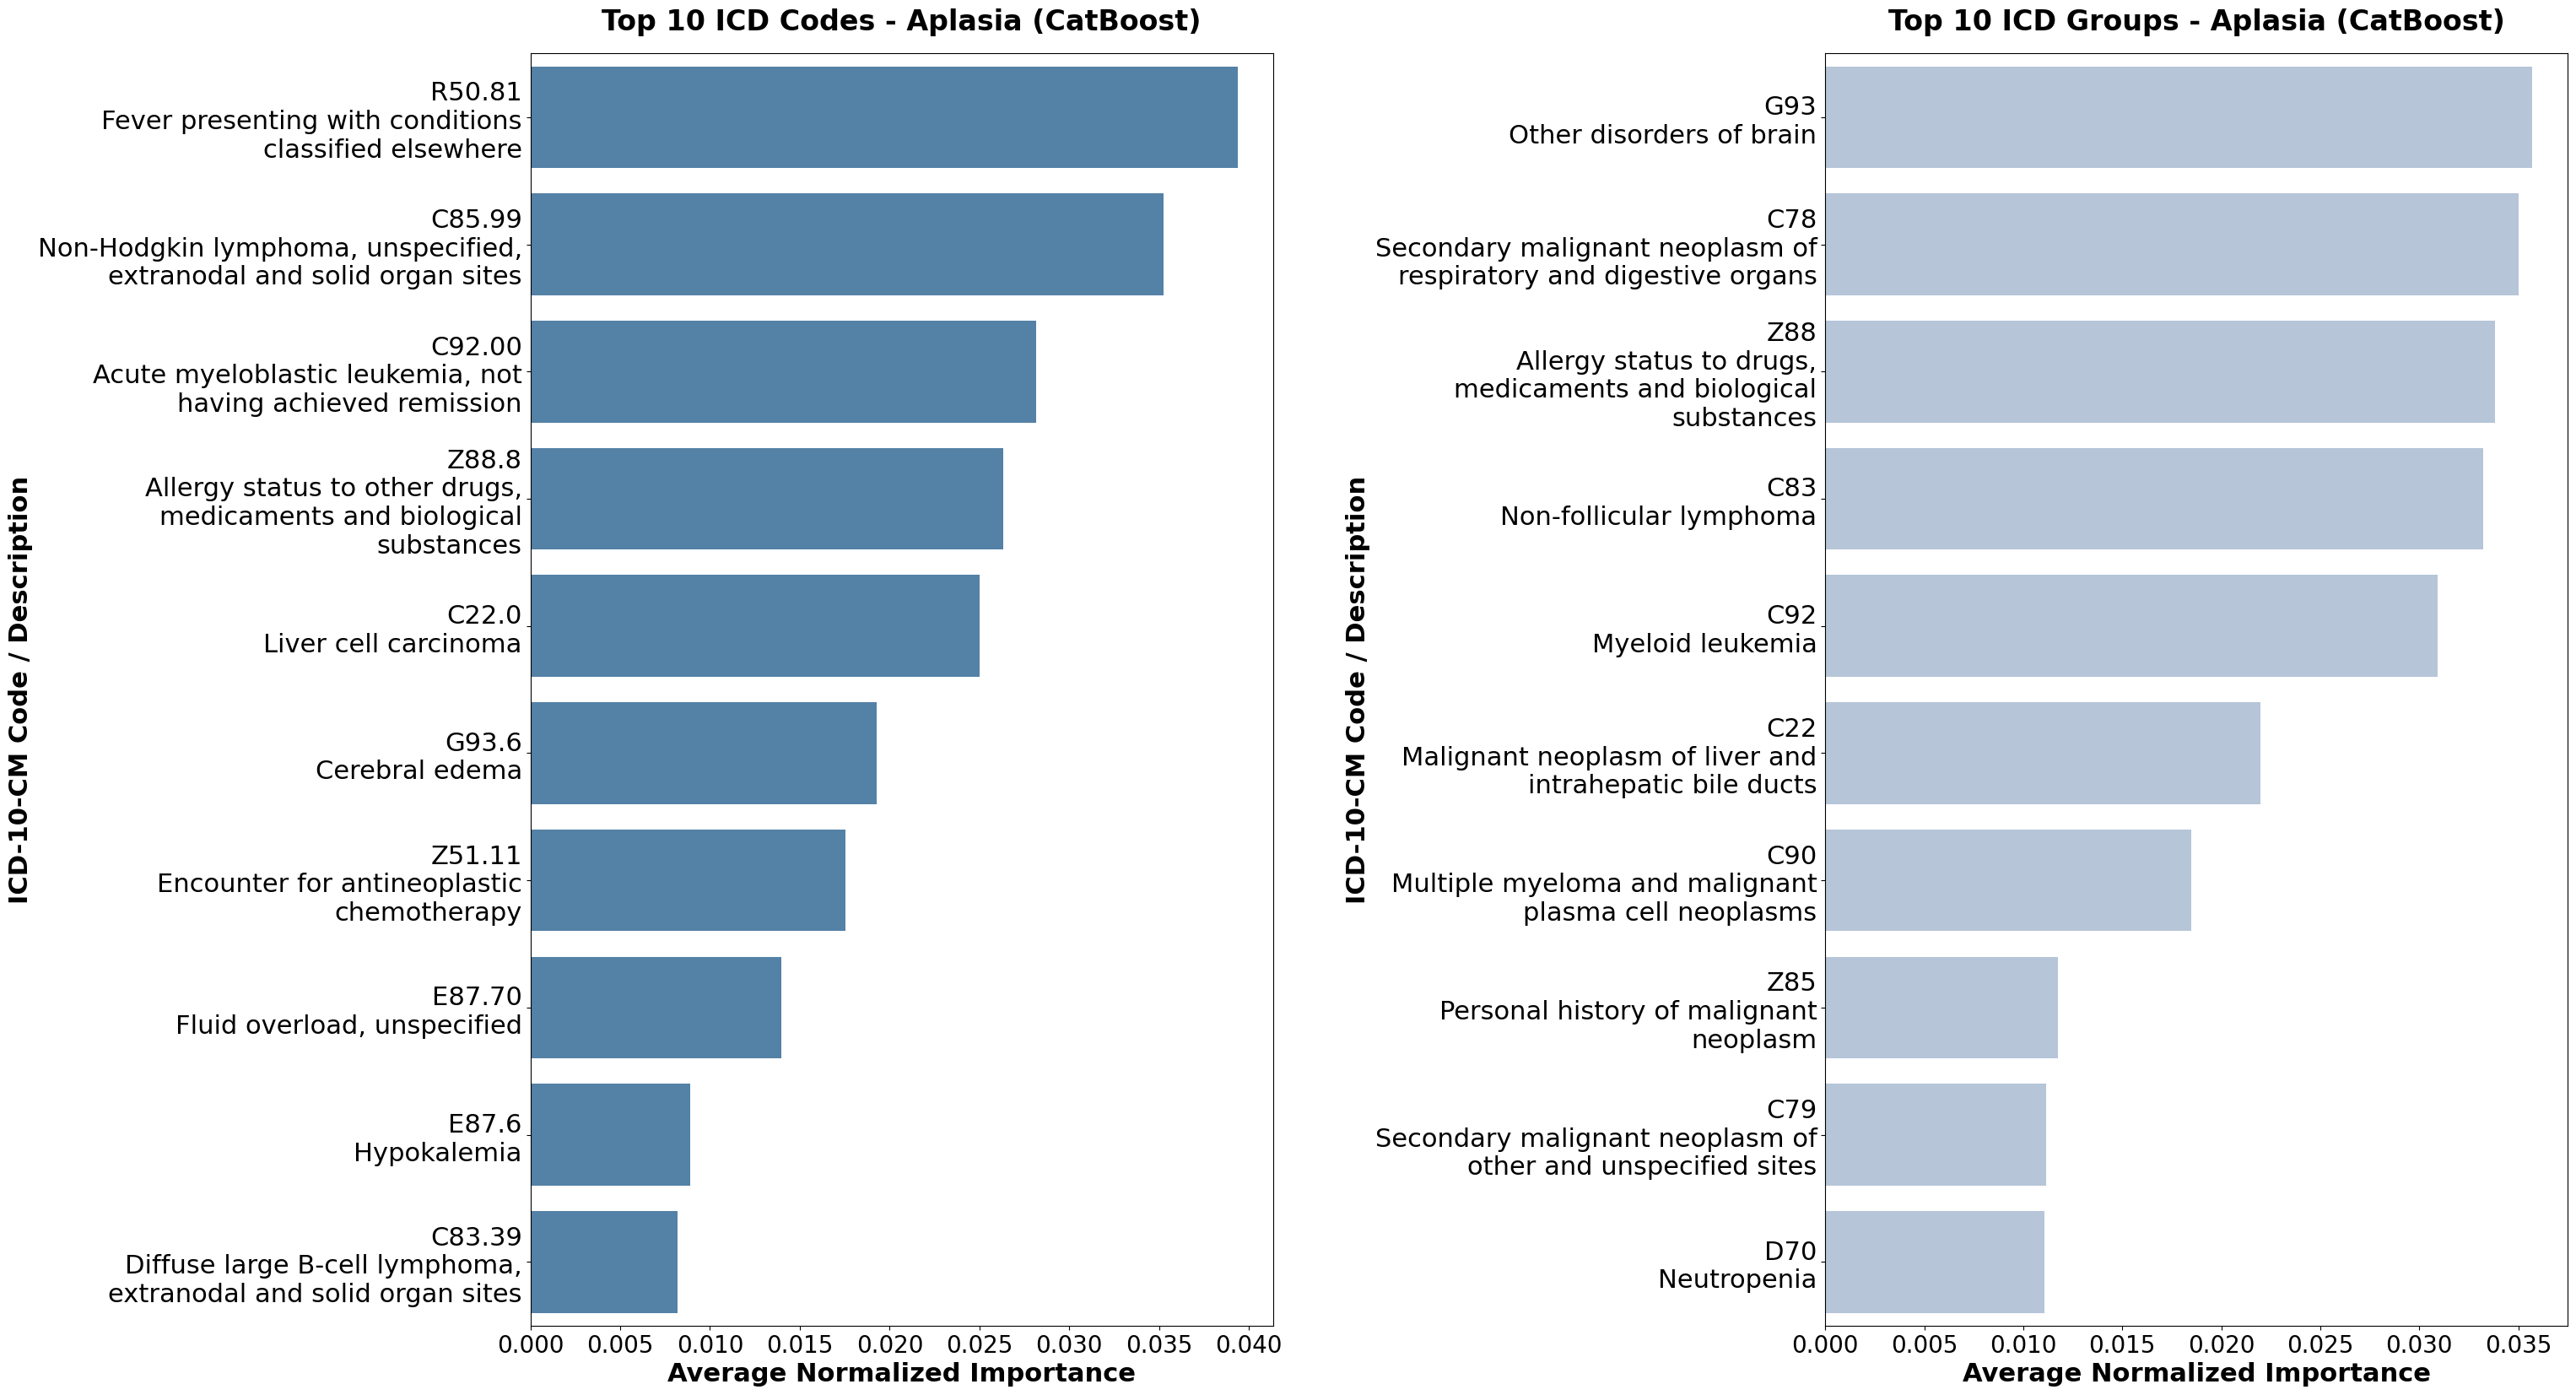

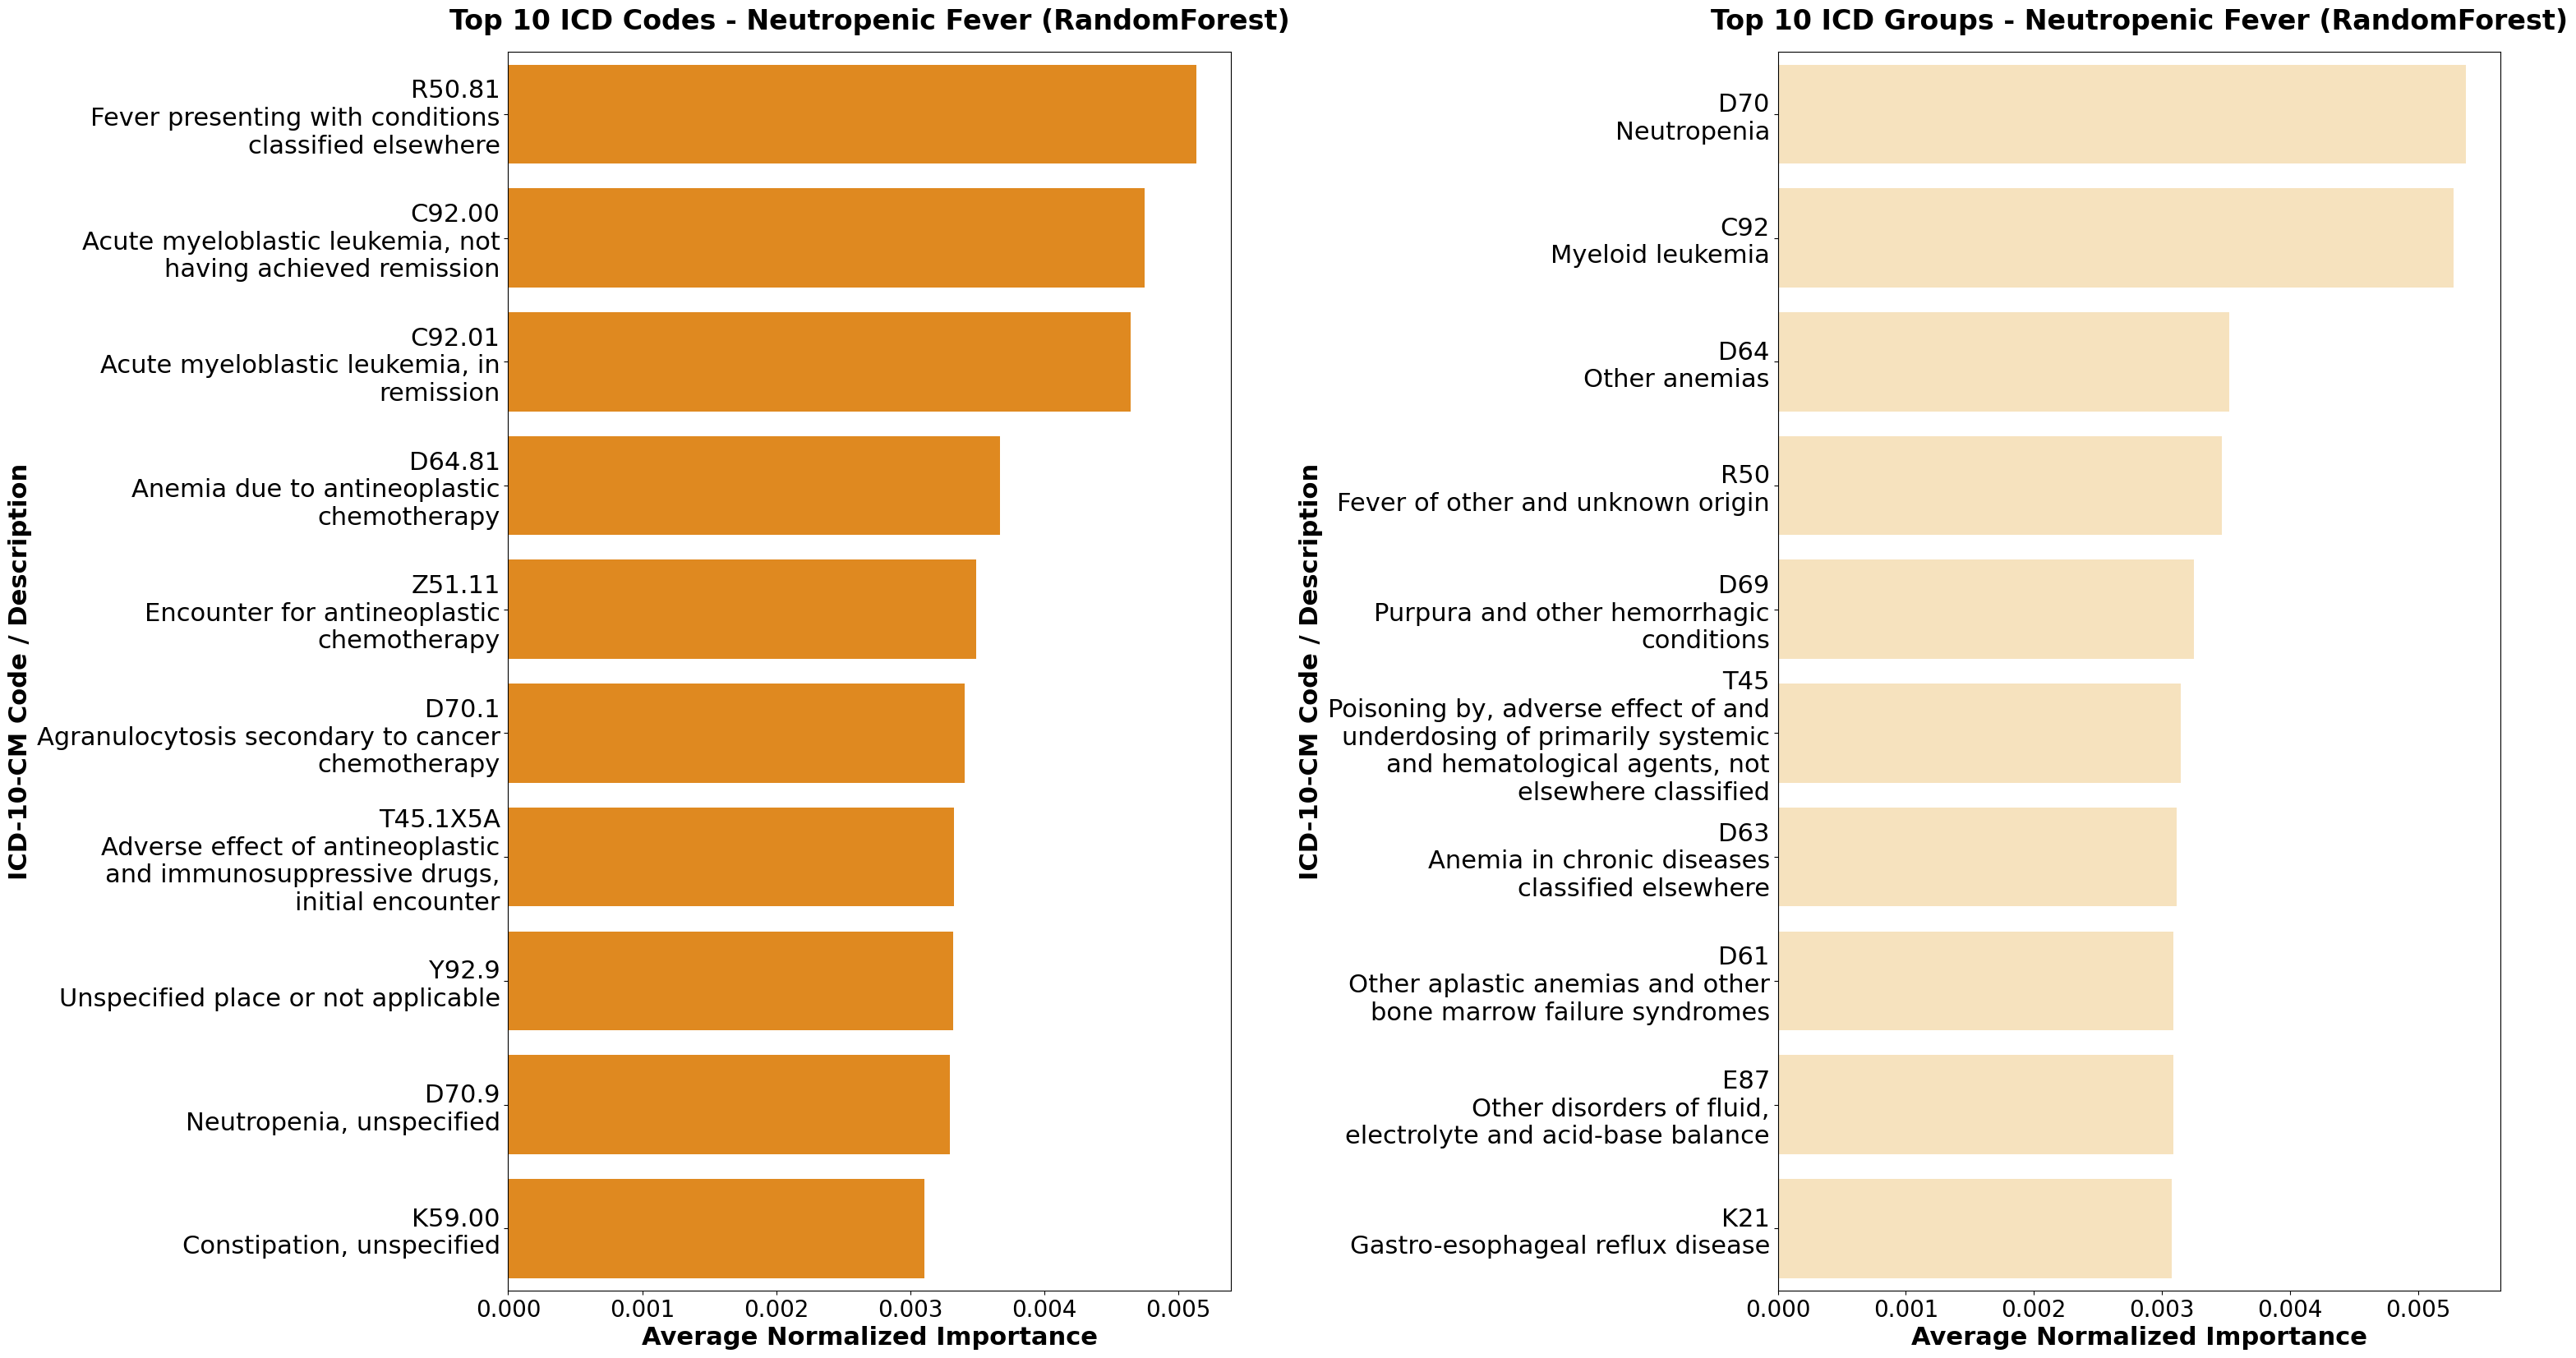

In [24]:
import textwrap

def format_icd_and_desc(code):
    clean_code = str(code).replace('.', '').strip().upper()
    
    if len(clean_code) > 3:
        fmt_code = f"{clean_code[:3]}.{clean_code[3:]}"
    else:
        fmt_code = clean_code
        
    try:
        desc = cm.get_description(fmt_code)
    except ValueError:
        desc = "Description Needed"
        
    wrapped_desc = "\n".join(textwrap.wrap(desc, width=35))
    return f"{fmt_code}\n{wrapped_desc}"

def plot_subplot(df, ax, title, color):
    plot_df = df.head(10).copy()
    plot_df['Feature'] = plot_df['Feature'].apply(format_icd_and_desc)
    
    sns.barplot(data=plot_df, x='Importance', y='Feature', color=color, ax=ax)
    
    ax.set_title(title, fontsize=24, fontweight='bold', pad=20) 
    ax.set_xlabel('Average Normalized Importance', fontsize=22, fontweight='bold') 
    ax.set_ylabel('ICD-10-CM Code / Description', fontsize=22, fontweight='bold') 
    
    ax.tick_params(axis='y', labelsize=22) 
    ax.tick_params(axis='x', labelsize=20)

# Aplasia
fig1, axes1 = plt.subplots(1, 2, figsize=(32, 18)) 

plot_subplot(aplasia_full, axes1[0], 'Top 10 ICD Codes - Aplasia (CatBoost)', 'steelblue')
plot_subplot(aplasia_groups, axes1[1], 'Top 10 ICD Groups - Aplasia (CatBoost)', 'lightsteelblue')

plt.tight_layout(pad=6.0)
plt.savefig(FIGURES_DIR / 'feature_importance_aplasia.png', dpi=300, bbox_inches='tight')
plt.show()

# Neutropenic Fever
fig2, axes2 = plt.subplots(1, 2, figsize=(32, 18)) 

plot_subplot(nf_full, axes2[0], 'Top 10 ICD Codes - Neutropenic Fever (RandomForest)', 'darkorange')
plot_subplot(nf_groups, axes2[1], 'Top 10 ICD Groups - Neutropenic Fever (RandomForest)', 'moccasin')

plt.tight_layout(pad=6.0)
plt.savefig(FIGURES_DIR / 'feature_importance_nf.png', dpi=300, bbox_inches='tight')
plt.show()